# Lavaca Bay SFINCS Tutorial — CLI Workflow

This notebook demonstrates how to build and run a
[SFINCS](https://sfincs.readthedocs.io) coastal flood model for
Lavaca Bay, Texas using the `coastal-calibration` command-line interface.

The workflow has two phases:

1. **Create** — build a SFINCS model from an Area of Interest (AOI)
   polygon using HydroMT-SFINCS.  This produces the grid, elevation,
   subgrid tables, and boundary conditions.
2. **Run** — execute the full simulation pipeline: download forcing
   data, write SFINCS input files, run the model, and compare results
   against NOAA tide-gauge observations.

## Setup

Change to the `texas-lavaca/` directory so that relative paths in
the YAML configs resolve correctly.

In [ ]:
from __future__ import annotations

import os
from pathlib import Path

notebook_dir = Path.cwd()  # assumes notebook is run from docs/examples/notebooks/
os.chdir(notebook_dir.parent / "texas-lavaca")
print("Working directory:", Path.cwd())

Working directory: /Users/tchegini/repos/nwm-coastal-dev/docs/examples/texas-lavaca


## 1. Create the SFINCS model

### Explore the create configuration

The `create.yaml` file specifies the AOI, grid resolution, elevation
datasets, mask thresholds, and subgrid parameters.

In [ ]:
print(Path("create.yaml").read_text())

# Lavaca Bay, Texas — SFINCS model creation from AOI
#
# Creates a quadtree mesh using HydroMT-SFINCS. The resulting model
# directory (./output) can be used as ``prebuilt_dir`` in the run config.
#
# Usage:
#   coastal-calibration create create.yaml
#   coastal-calibration create create.yaml --dry-run

aoi: ./aoi.geojson
output_dir: ./output
download_dir: ../downloads/lavaca_grid

grid:
  resolution: 512        # base resolution in meters
  crs: utm               # auto-detect UTM zone (-> EPSG:32614)
  rotated: false
  refinement:
  - polygon: ./refine.geojson     # refine interior to 64 m (512 / 2^3)
    level: 3                      # 3 refinement steps: 512->256->128->64 m

elevation:
  datasets:
  - name: noaa_3m                 # auto-fetched from NOAA S3
    zmin: -20000
    source: noaa_3m               # triggers NOAA DEM auto-discovery for AOI
  - name: gebco_15arcs            # global fallback for areas without NOAA coverage
    zmin: -20000
    source: gebco_15arcs        

### Run the create workflow

This downloads elevation data (NOAA 3 m topobathy + GEBCO bathymetry)
and ESA WorldCover land-use, then builds the quadtree grid, elevation,
mask, boundary conditions, and subgrid tables.

In [ ]:
!coastal-calibration create create.yaml

Coastal Calibration Workflow                                                    
Start Time: 2026-03-04 15:16:56                                                 
----------------------------------------                                        
Stage: create_grid                                                              
Start Time: 2026-03-04 15:16:56                                                 
  Create SFINCS grid from AOI                                                   
  AOI:                                                                          
/Users/tchegini/repos/nwm-coastal-dev/docs/examples/texas-lavaca/aoi.geojson    
  Resolution: 512 m, CRS: utm                                                   
  Refinement: 1 polygon(s), max level 3                                         
  Grid created successfully                                                     
  [✓] COMPLETED (0s)                                                            
----------------------------

### Inspect the created model

The output directory now contains all SFINCS model files.

In [ ]:
output = Path("output")
assert output.exists(), (
    f"Output directory not found: {output.resolve()} — run the create command first."
)

for f in sorted(output.iterdir()):
    if f.name.startswith(".") or f.suffix == ".log":
        continue
    size = f.stat().st_size
    label = f"{size / 1e6:.1f} MB" if size > 1e6 else f"{size / 1e3:.1f} KB"
    print(f"  {f.name:<30s} {label}")

  create_progress.json           2.0 KB
  create_result.json             1.1 KB
  gis                            0.1 KB
  obs_station_map.json           0.5 KB
  sfincs.inp                     0.9 KB
  sfincs.nc                      5.8 MB
  sfincs.obs                     0.2 KB
  sfincs_subgrid.nc              9.1 MB
  subgrid                        0.2 KB


## 2. Run the simulation pipeline

### Explore the run configuration

The `run.yaml` file configures the simulation period, boundary source,
download paths, and SFINCS runtime parameters.

In [ ]:
print(Path("run.yaml").read_text())

# Lavaca Bay, Texas — SFINCS run pipeline configuration
#
# Uses the model created via:
#   coastal-calibration create create.yaml
#
# Quadtree mesh, EPSG:32614 (UTM zone 14N), 512 m base resolution
#
# Usage:
#   coastal-calibration run run.yaml
#   coastal-calibration run run.yaml --stop-after sfincs_write
#   coastal-calibration run run.yaml --start-from sfincs_run

model: sfincs

simulation:
  start_date: 2025-06-01
  duration_hours: 10
  coastal_domain: atlgulf
  meteo_source: nwm_ana  # nwm_retro ends 2023 and stofs starts from 2021

boundary:
  source: stofs

paths:
  work_dir: ./run
  raw_download_dir: ../downloads    # shared download cache

download:
  enabled: true

model_config:
  prebuilt_dir: ./output            # created by: coastal-calibration create create.yaml
  # discharge_locations_file: ./output/sfincs_nwm.src
  merge_discharge: true
  forcing_to_mesh_offset_m: 0.0    # STOFS already in NAVD88
  vdatum_mesh_to_msl_m: 0.30       # NAVD88 mesh -> MSL (0.17 datum + ~0

### Note on the SFINCS executable

The `sfincs_exe` field in `run.yaml` points to a compiled SFINCS binary.
You have two options:

1. **Compile SFINCS** yourself and update the path in the config if it
   differs from `~/.local/bin/sfincs`.
2. **Use Singularity** — comment out the `sfincs_exe` line entirely.
   The pipeline will then use the `ngen-coastal.sif` Singularity image.

If neither is available, the pipeline will complete all stages up to
`sfincs_run` (downloading data, writing inputs) and then fail at the
model execution step.  You can re-start from that point later with
`--start-from sfincs_run`.

### Run the pipeline

In [ ]:
!coastal-calibration run run.yaml

Coastal Calibration Workflow                                                    
Start Time: 2026-03-04 15:18:19                                                 
----------------------------------------                                        
Stage: download                                                                 
Start Time: 2026-03-04 15:18:19                                                 
  Download input data (NWM, STOFS)                                              
  meteo/nwm_ana: 11/11 [OK]                                                     
  hydro/nwm: 11/11 [OK]                                                         
  coastal/stofs: 1/1 [OK]                                                       
  Total: 23/23 (failed: 0)                                                      
  Download complete — raw files stored in                                       
/Users/tchegini/repos/nwm-coastal-dev/docs/examples/downloads                   
  [✓] COMPLETED (1s)        

## 3. View results

The pipeline generates station comparison plots (modelled vs. observed
water levels at NOAA CO-OPS tide gauges).

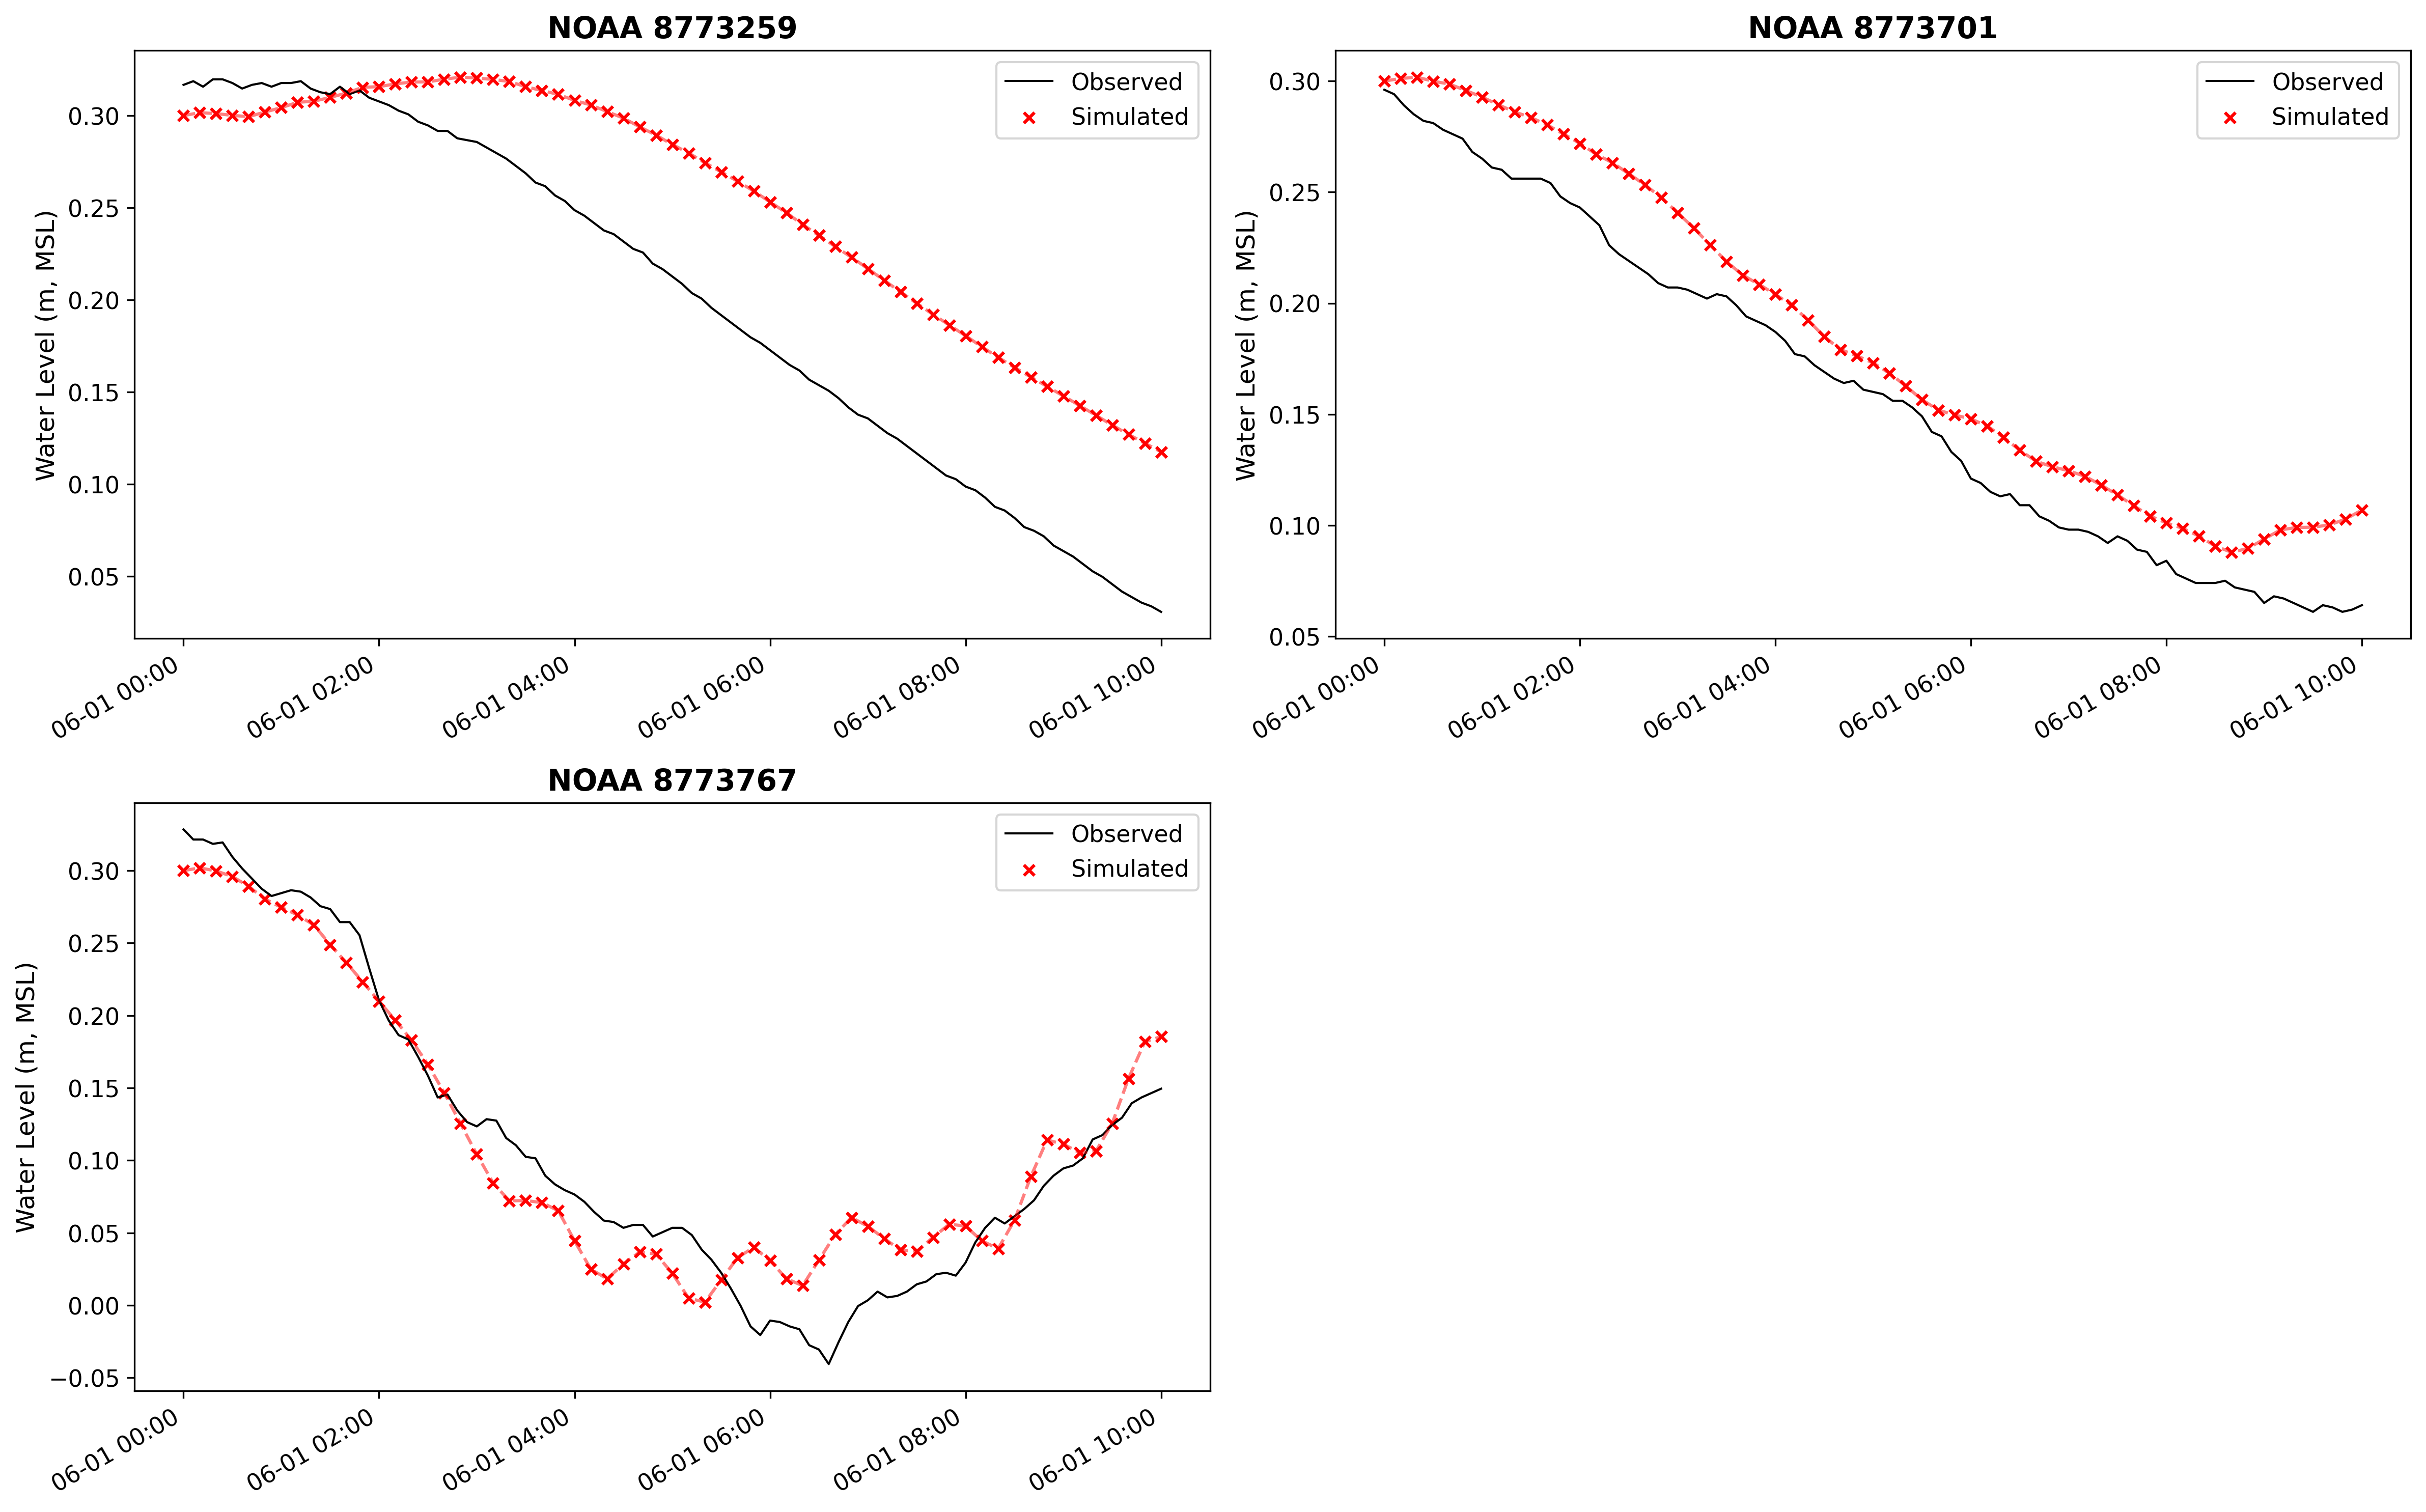

In [ ]:
from IPython.display import Image, display

figs_dir = Path("run/sfincs_model/figs")
assert figs_dir.exists(), f"Results not found: {figs_dir.resolve()} — run the pipeline first."

for png in sorted(figs_dir.glob("stations_comparison_*.png")):
    display(Image(filename=str(png), width=800))

## Summary

This notebook demonstrated the full Lavaca Bay SFINCS workflow via the CLI:

1. `coastal-calibration create create.yaml` — built the model from an AOI
2. `coastal-calibration run run.yaml` — downloaded data, ran SFINCS, and
   compared results against NOAA observations